In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import price_option_tree, price_option_tree_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import price_option_bsm
from greeks import delta_bsm, theta_bsm, gamma_bsm, vega_bsm, rho_bsm, delta_tree, theta_tree, gamma_tree, vega_tree, rho_tree

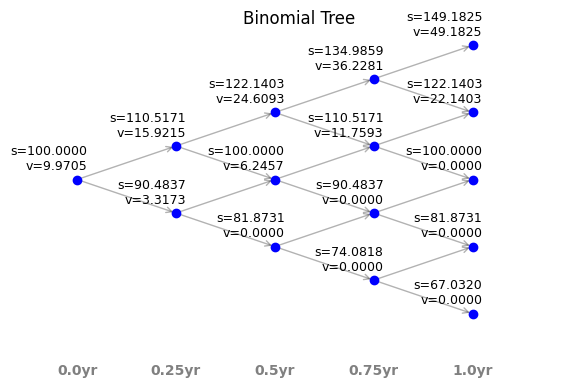

In [2]:
price, stocks, options, timeline = price_option_tree(option_type="call", exercise_style="American", s=100, k=100,
                                                sigma=0.2, T=1, N=4, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

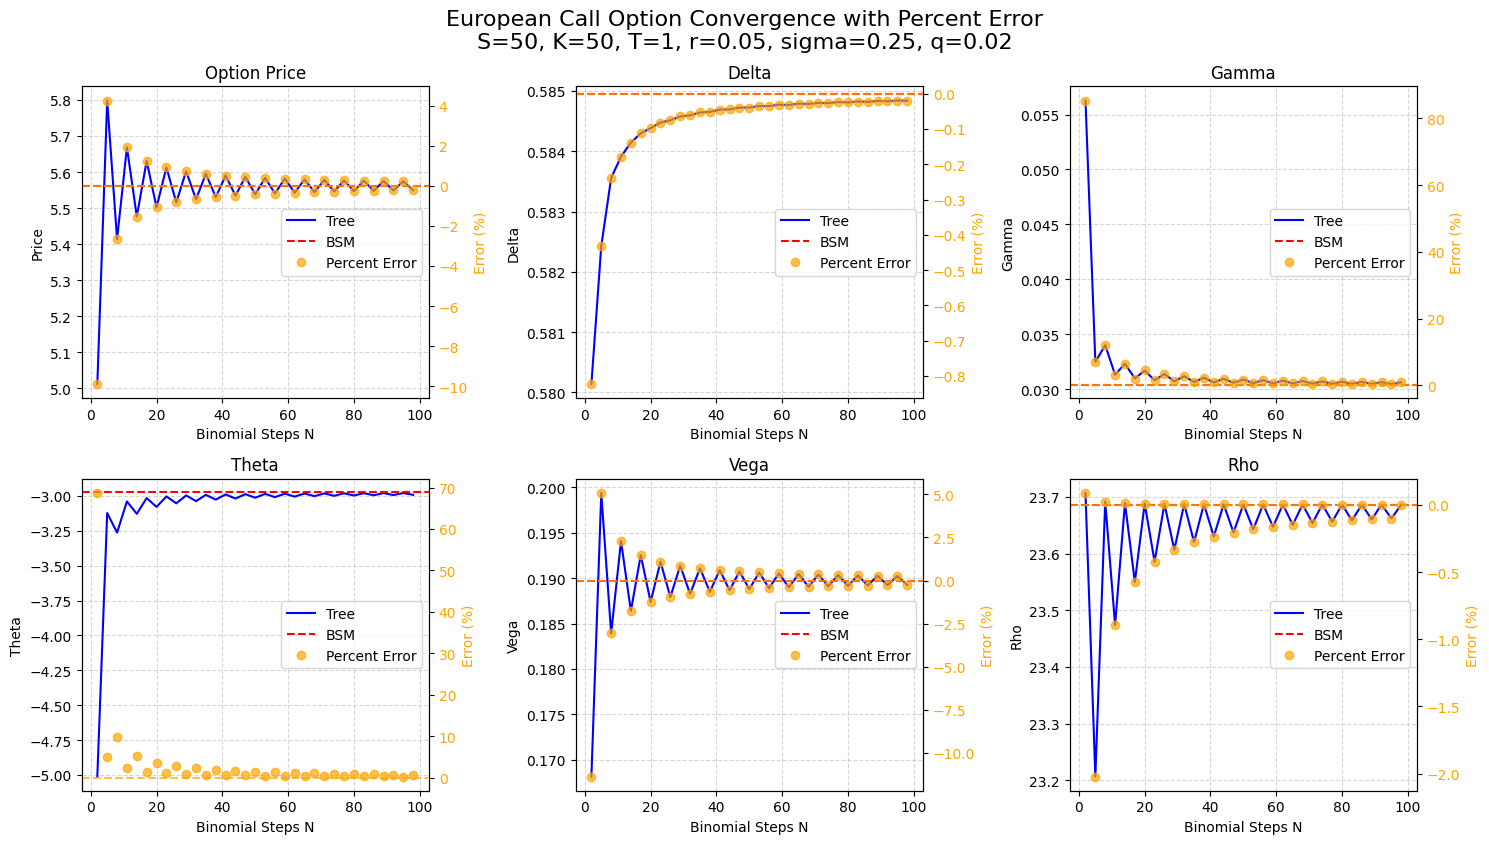

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
s = 50
k = 50
T = 1
r = 0.05
sigma = 0.25
q = 0.02
option_type = 'call'
exercise_style = 'European'

# Number of binomial steps
N_vals = np.arange(2, 100, 3)

# Containers for convergence
price_tree_vals = []
delta_tree_vals = []
gamma_tree_vals = []
theta_tree_vals = []
vega_tree_vals = []
rho_tree_vals = []

# Compute BSM values
price_bsm = price_option_bsm(option_type, exercise_style, s, k, T, r, q, sigma)
delta_bsm_val = delta_bsm(option_type, s, k, r, sigma, T, q)
gamma_bsm_val = gamma_bsm(s, k, r, sigma, T, q)
theta_bsm_val = theta_bsm(option_type, s, k, r, sigma, T, q)
vega_bsm_val = vega_bsm(s, k, r, sigma, T, q)
rho_bsm_val = rho_bsm(option_type, s, k, r, sigma, T, q)

epsilon_vega = 1e-4
epsilon_rho = 1e-4

# Compute Tree values
for N in N_vals:
    price_tree_vals.append(price_option_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, return_tree=False))
    delta_tree_vals.append(delta_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    gamma_tree_vals.append(gamma_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    theta_tree_vals.append(theta_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    vega_tree_vals.append(vega_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=epsilon_vega))
    rho_tree_vals.append(rho_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=epsilon_rho))

# --- Plotting in 2x3 panels with percent error ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

greeks_tree = [price_tree_vals, delta_tree_vals, gamma_tree_vals,
               theta_tree_vals, vega_tree_vals, rho_tree_vals]
greeks_bsm = [price_bsm, delta_bsm_val, gamma_bsm_val,
              theta_bsm_val, vega_bsm_val, rho_bsm_val]
titles = ['Option Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']
ylabels = ['Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']

for i, ax in enumerate(axes):
    tree_vals = greeks_tree[i]
    bsm_val = greeks_bsm[i]
    
    # Tree values (line)
    ax.plot(N_vals, tree_vals, label='Tree', color='blue')
    ax.axhline(bsm_val, color='red', linestyle='--', label='BSM')
    ax.set_xlabel('Binomial Steps N')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    
    # Percent error on right y-axis (dots)
    ax2 = ax.twinx()
    percent_error = 100 * (np.array(tree_vals) - bsm_val) / bsm_val
    ax2.plot(N_vals, percent_error, 'o', color='orange', label='Percent Error', alpha=0.7)
    ax2.set_ylabel('Error (%)', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.axhline(0, color='orange', linestyle='--', alpha=0.7)

    lines_ax, labels_ax = ax.get_legend_handles_labels()
    lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    ax.legend(lines_ax + lines_ax2, labels_ax + labels_ax2, loc='center right')

# Layout and super title
plt.tight_layout()
param_title = (f"European {option_type.capitalize()} Option Convergence with Percent Error\n"
               f"S={s}, K={k}, T={T}, r={r}, sigma={sigma}, q={q}")
fig.suptitle(param_title, fontsize=16, y=1.05)
plt.show()

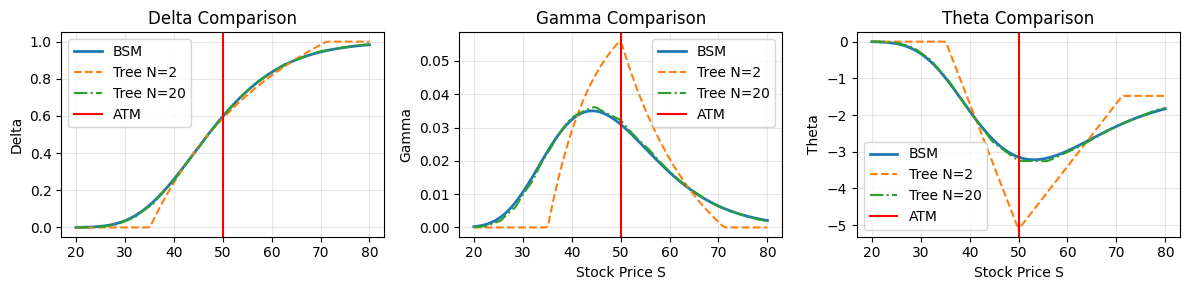

In [38]:
# Parameters
s_vals = np.linspace(20, 80, 100)
k = 50
T = 1
r = 0.03
sigma = 0.25
q = 0.0
option_type = 'call'
exercise_style = 'European'

N_small = 2
N_medium = 20

# Compute BSM Greeks
delta_bsm_vals = np.array([delta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])
gamma_bsm_vals = np.array([gamma_bsm(s, k, r, sigma, T, q) for s in s_vals])
theta_bsm_vals = np.array([theta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])

# Compute Tree Greeks (N=2)
delta_tree_2 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
gamma_tree_2 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
theta_tree_2 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])

# Compute Tree Greeks (N=20)
delta_tree_20 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
gamma_tree_20 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
theta_tree_20 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# delta
axes[0].plot(s_vals, delta_bsm_vals, label='BSM', linewidth=2)
axes[0].plot(s_vals, delta_tree_2, label='Tree N=2', linestyle='--')
axes[0].plot(s_vals, delta_tree_20, label='Tree N=20', linestyle='-.')
axes[0].axvline(k, color='r', linestyle='-', label='ATM')
axes[0].set_title('Delta Comparison')
axes[0].set_ylabel('Delta')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# gamma
axes[1].plot(s_vals, gamma_bsm_vals, label='BSM', linewidth=2)
axes[1].plot(s_vals, gamma_tree_2, label='Tree N=2', linestyle='--')
axes[1].plot(s_vals, gamma_tree_20, label='Tree N=20', linestyle='-.')
axes[1].axvline(k, color='r', linestyle='-', label='ATM')
axes[1].set_title('Gamma Comparison')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Gamma')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# theta
axes[2].plot(s_vals, theta_bsm_vals, label='BSM', linewidth=2)
axes[2].plot(s_vals, theta_tree_2, label='Tree N=2', linestyle='--')
axes[2].plot(s_vals, theta_tree_20, label='Tree N=20', linestyle='-.')
axes[2].axvline(k, color='r', linestyle='-', label='ATM')
axes[2].set_title('Theta Comparison')
axes[2].set_xlabel('Stock Price S')
axes[2].set_ylabel('Theta')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

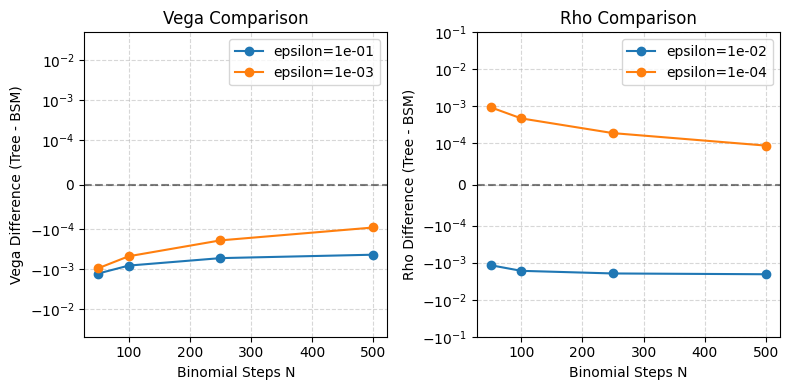

In [69]:
# Parameters
s = 50
k = 50
T = 1
r = 0.03
sigma = 0.25
q = 0.0
option_type = 'call'
exercise_style = 'European'

N_vals = np.array([50, 100, 250, 500])

# Epsilon values
epsilon_vega = [1e-1, 1e-3]
epsilon_rho = [1e-2, 1e-4]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# vega
ax = axes[0]
for eps in epsilon_vega:
    diff_list = []
    for N in N_vals:
        vega_bsm_val = vega_bsm(s, k, r, sigma, T, q)
        vega_tree_val = vega_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=eps)
        diff_list.append(vega_tree_val - vega_bsm_val)
    ax.plot(N_vals, diff_list, marker='o', label=f'epsilon={eps:.0e}')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_ylim(-5e-2, 5e-2)
ax.set_xlabel('Binomial Steps N')
ax.set_ylabel('Vega Difference (Tree - BSM)')
ax.set_title('Vega Comparison')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# rho
ax = axes[1]
for eps in epsilon_rho:
    diff_list = []
    for N in N_vals:
        rho_bsm_val = rho_bsm(option_type, s, k, r, sigma, T, q)
        rho_tree_val = rho_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=eps)
        diff_list.append(rho_tree_val - rho_bsm_val)
    ax.plot(N_vals, diff_list, marker='o', label=f'epsilon={eps:.0e}')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_ylim(-1e-1, 1e-1)
ax.set_xlabel('Binomial Steps N')
ax.set_ylabel('Rho Difference (Tree - BSM)')
ax.set_title('Rho Comparison')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()